# 80-epoch CenterNet training artifact dashboard

This notebook turns the artifacts in `outputs/models/80 epochs` into a compact model-development dashboard. It covers optimization, legacy pixel-gated center detection, normalized validation metrics, raw-to-spine-chain effects, source and vertebra-scale robustness, Cobb geometry agreement, and per-instance landmark errors.

**Interpretation boundaries**

- `raw` means decoded network detections; `spine_chain` means detections after the fixed anatomical-chain post-processing stage. They are always shown separately.
- `D` is the ground-truth vertebral bounding-box diagonal. The saved 80-epoch artifacts expose center gates at **0.10D, 0.20D, and 0.25D**. They do not contain a 0.15D time series, so this notebook does not interpolate one.
- Corner order is **TL, TR, BL, BR**. NME is normalized by the ground-truth vertebral diagonal; PCK@0.10 is the fraction of corners within 0.10D.
- Cobb outputs are geometric agreement measures for screening-model research, not diagnostic accuracy.
- The `.pt` files are inventoried but not deserialized; all plots use the CSV/JSON artifacts, keeping the notebook fast and avoiding loading about 600 MiB of weights.

## 1. Setup and artifact discovery

Required libraries: `numpy`, `pandas`, `matplotlib`, and `seaborn`. If needed, run `python -m pip install numpy pandas matplotlib seaborn`. Set `SAVE_FIGURES = True` to export PNG copies beside this notebook.

In [2]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_project_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "outputs" / "models" / "80 epochs").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate outputs/models/80 epochs from the current working directory.")

PROJECT_ROOT = find_project_root()
ARTIFACT_ROOT = PROJECT_ROOT / "outputs" / "models" / "80 epochs"
FIGURE_ROOT = PROJECT_ROOT / "notebooks" / "preview" / "80_epoch_training_figures"
SAVE_FIGURES = False
if SAVE_FIGURES:
    FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

RAW_COLOR = "#5B8FF9"
CHAIN_COLOR = "#F6BD16"
TRAIN_COLOR = "#5AD8A6"
VAL_COLOR = "#E8684A"
SNAPSHOT_COLORS = {
    "best usable (e49)": "#5B8FF9",
    "best corner NME (e70)": "#61DDAA",
    "last (e80)": "#E8684A",
}

def finish_figure(fig, name):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_ROOT / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()

print(f"Project root:  {PROJECT_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")

Project root:  /Users/gcpuppy/Documents/AI/Spinal AI/Spine-Opportunistic-Screening
Artifact root: /Users/gcpuppy/Documents/AI/Spinal AI/Spine-Opportunistic-Screening/outputs/models/80 epochs


In [3]:
required_files = [
    "train_log.csv",
    "validation_landmark_log.csv",
    "best_usable_recall_metrics.json",
    "best_corner_nme_metrics.json",
    "validation_metrics_latest.json",
    "best_usable_recall_instances.csv",
    "best_corner_nme_instances.csv",
    "validation_instances_latest.csv",
]
missing = [name for name in required_files if not (ARTIFACT_ROOT / name).is_file()]
if missing:
    raise FileNotFoundError(f"Missing required artifacts: {missing}")

train = pd.read_csv(ARTIFACT_ROOT / "train_log.csv").sort_values("epoch").reset_index(drop=True)
landmark = pd.read_csv(ARTIFACT_ROOT / "validation_landmark_log.csv").sort_values("epoch").reset_index(drop=True)

metric_specs = {
    "best usable (e49)": "best_usable_recall_metrics.json",
    "best corner NME (e70)": "best_corner_nme_metrics.json",
    "last (e80)": "validation_metrics_latest.json",
}
metrics_payloads = {
    label: json.loads((ARTIFACT_ROOT / filename).read_text())
    for label, filename in metric_specs.items()
}

instance_specs = {
    "best usable (e49)": "best_usable_recall_instances.csv",
    "best corner NME (e70)": "best_corner_nme_instances.csv",
    "last (e80)": "validation_instances_latest.csv",
}
instance_frames = []
for label, filename in instance_specs.items():
    frame = pd.read_csv(ARTIFACT_ROOT / filename, low_memory=False)
    frame["snapshot"] = label
    frame["epoch"] = metrics_payloads[label]["epoch"]
    for column in ("usable", "inside_image", "valid_quadrilateral"):
        if column in frame:
            frame[column] = frame[column].astype(str).str.lower().map({"true": True, "false": False})
    instance_frames.append(frame)
instances = pd.concat(instance_frames, ignore_index=True)

# Fail early if the files do not describe the expected run.
assert train["epoch"].tolist() == list(range(1, 81)), "train_log.csv must contain unique epochs 1-80"
assert landmark["epoch"].tolist() == list(range(49, 81)), "landmark log must contain epochs 49-80"
assert {payload["epoch"] for payload in metrics_payloads.values()} == {49, 70, 80}
assert {payload["images"] for payload in metrics_payloads.values()} == {223}
assert set(instances["model"].dropna().unique()) == {"raw", "spine_chain"}
assert instances["source_dataset"].nunique() == 5

inventory = []
for path in sorted(ARTIFACT_ROOT.iterdir()):
    if path.is_file():
        inventory.append({"artifact": path.name, "MiB": path.stat().st_size / 2**20})
display(pd.DataFrame(inventory).style.format({"MiB": "{:.2f}"}))
print(f"Loaded {len(train)} training epochs, {len(landmark)} detailed-validation epochs, and {len(instances):,} instance rows.")

,artifact,MiB
0,best_center_f1.pt,152.09
1,best_corner_nme.pt,152.09
2,best_corner_nme_instances.csv,3.98
3,best_corner_nme_metrics.json,0.19
4,best_usable_recall.pt,152.11
5,best_usable_recall_instances.csv,4.00
6,best_usable_recall_metrics.json,0.19
7,last.pt,151.96
8,train_log.csv,0.03
9,validation_instances_latest.csv,3.98


Loaded 80 training epochs, 32 detailed-validation epochs, and 19,692 instance rows.


## 2. Run overview and checkpoint-selection events

The run has dense optimization/legacy-center metrics for all 80 epochs. The detailed normalized validation scorecard starts at epoch 49. Three scorecard snapshots were saved at epochs 49, 70, and 80; the best-center checkpoint is inferred from the 12-pixel F1 peak in the training log (epoch 69).

In [4]:
best_center_epoch = int(train.loc[train["center_f1_12px"].idxmax(), "epoch"])
checkpoint_epochs = {
    "best_usable_recall.pt": int(metrics_payloads["best usable (e49)"]["epoch"]),
    "best_center_f1.pt": best_center_epoch,
    "best_corner_nme.pt": int(metrics_payloads["best corner NME (e70)"]["epoch"]),
    "last.pt": int(metrics_payloads["last (e80)"]["epoch"]),
}

selection_rows = []
train_by_epoch = train.set_index("epoch")
landmark_by_epoch = landmark.set_index("epoch")
for checkpoint, epoch in checkpoint_epochs.items():
    t = train_by_epoch.loc[epoch]
    l = landmark_by_epoch.loc[epoch]
    selection_rows.append({
        "checkpoint": checkpoint,
        "epoch": epoch,
        "val_loss": t["val_loss"],
        "center_f1_12px": t["center_f1_12px"],
        "raw_f1_0.20D": l["raw_center_f1_0.20d"],
        "chain_f1_0.20D": l["spine_chain_center_f1_0.20d"],
        "chain_corner_nme": l["spine_chain_corner_nme_mean"],
        "chain_pck_0.10": l["spine_chain_pck_0.10"],
        "chain_usable_recall": l["spine_chain_usable_vertebra_recall"],
        "chain_fp_per_image": l["spine_chain_false_positives_per_image"],
        "chain_count_mae": l["spine_chain_count_mae"],
    })
selection = pd.DataFrame(selection_rows).sort_values("epoch").reset_index(drop=True)
display(selection.style.format({column: "{:.4f}" for column in selection.columns if column not in {"checkpoint", "epoch"}}))

extrema = pd.DataFrame([
    {"metric": "minimum validation loss", "epoch": int(train.loc[train.val_loss.idxmin(), "epoch"]), "value": train.val_loss.min()},
    {"metric": "maximum center F1 @ 12 px", "epoch": int(train.loc[train.center_f1_12px.idxmax(), "epoch"]), "value": train.center_f1_12px.max()},
    {"metric": "maximum chain F1 @ 0.20D", "epoch": int(landmark.loc[landmark["spine_chain_center_f1_0.20d"].idxmax(), "epoch"]), "value": landmark["spine_chain_center_f1_0.20d"].max()},
    {"metric": "minimum chain corner NME", "epoch": int(landmark.loc[landmark["spine_chain_corner_nme_mean"].idxmin(), "epoch"]), "value": landmark["spine_chain_corner_nme_mean"].min()},
    {"metric": "maximum chain PCK @ 0.10", "epoch": int(landmark.loc[landmark["spine_chain_pck_0.10"].idxmax(), "epoch"]), "value": landmark["spine_chain_pck_0.10"].max()},
    {"metric": "minimum chain count MAE", "epoch": int(landmark.loc[landmark["spine_chain_count_mae"].idxmin(), "epoch"]), "value": landmark["spine_chain_count_mae"].min()},
])
display(extrema.style.format({"value": "{:.5f}"}))

,checkpoint,epoch,val_loss,center_f1_12px,raw_f1_0.20D,chain_f1_0.20D,chain_corner_nme,chain_pck_0.10,chain_usable_recall,chain_fp_per_image,chain_count_mae
0,best_usable_recall.pt,49,1.1349,0.8934,0.9123,0.9406,0.0621,0.8476,0.8350,0.8161,0.8789
1,best_center_f1.pt,69,1.2206,0.9060,0.9214,0.9382,0.0611,0.8524,0.8306,0.7937,0.9013
2,best_corner_nme.pt,70,1.2133,0.9030,0.9167,0.9346,0.0608,0.8531,0.8263,0.8565,0.9372
3,last.pt,80,1.2246,0.9042,0.9211,0.9390,0.0612,0.8511,0.8269,0.8072,0.9283


,metric,epoch,value
0,minimum validation loss,35,1.05272
1,maximum center F1 @ 12 px,69,0.90603
2,maximum chain F1 @ 0.20D,49,0.94062
3,minimum chain corner NME,70,0.06080
4,maximum chain PCK @ 0.10,72,0.85367
5,minimum chain count MAE,63,0.82511


## 3. Optimization curves

Total and component losses reveal convergence, divergence between training and validation, and which objective terms dominate. The dashed vertical lines mark the four retained checkpoint epochs.

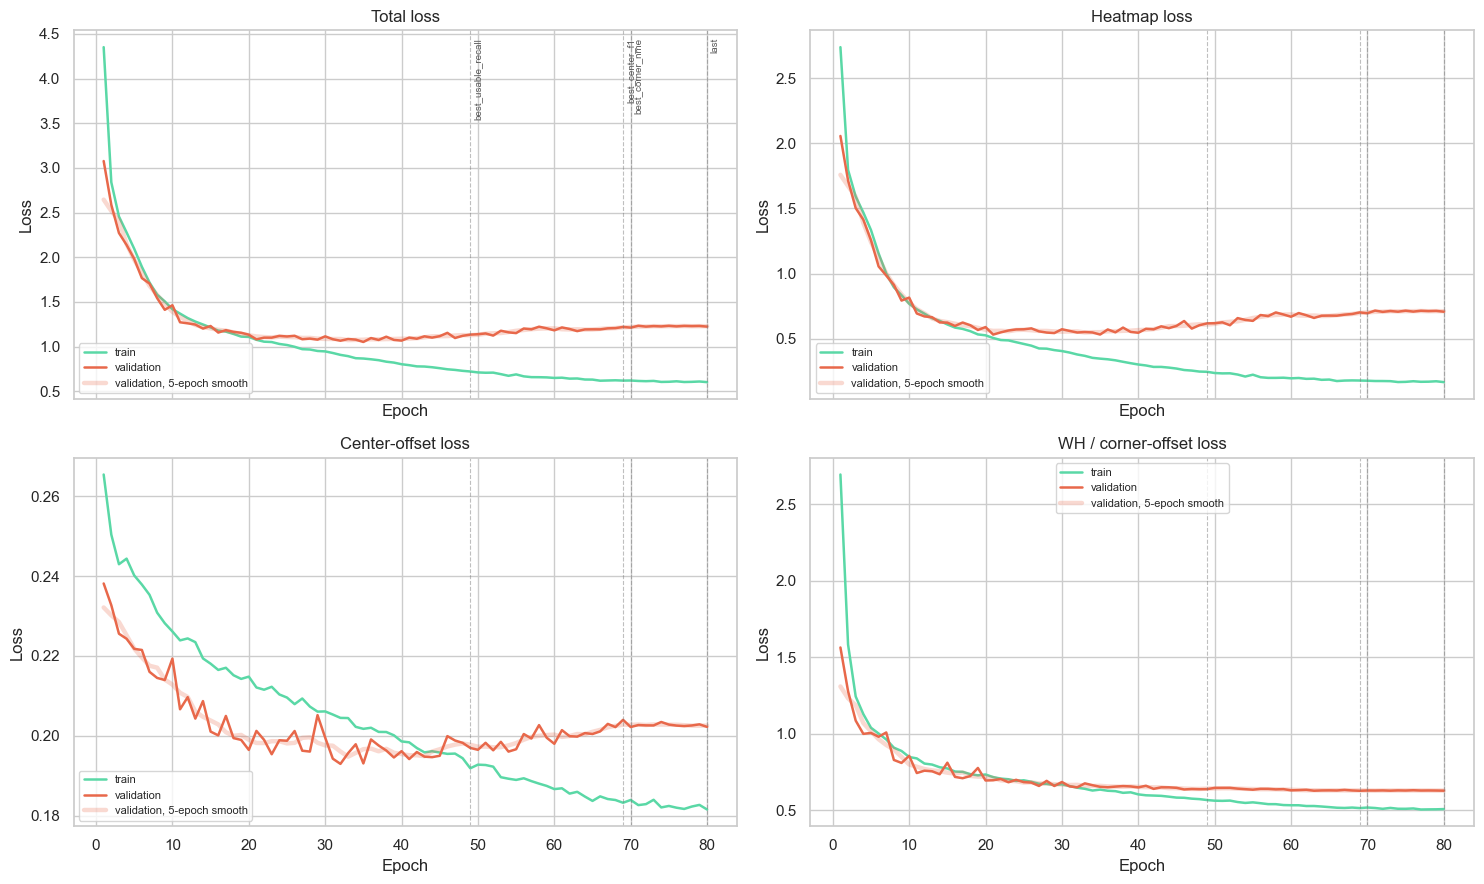

In [4]:
def mark_checkpoint_epochs(ax, labels=False):
    for checkpoint, epoch in checkpoint_epochs.items():
        ax.axvline(epoch, color="0.45", lw=0.8, ls="--", alpha=0.45)
        if labels:
            ax.text(epoch + 0.4, 0.98, checkpoint.replace(".pt", ""), rotation=90,
                    transform=ax.get_xaxis_transform(), va="top", ha="left", fontsize=7, color="0.35")

components = [
    ("loss", "Total loss"),
    ("hm_loss", "Heatmap loss"),
    ("reg_loss", "Center-offset loss"),
    ("wh_loss", "WH / corner-offset loss"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, (suffix, title) in zip(axes.flat, components):
    ax.plot(train.epoch, train[f"train_{suffix}"], color=TRAIN_COLOR, lw=1.8, label="train")
    ax.plot(train.epoch, train[f"val_{suffix}"], color=VAL_COLOR, lw=1.8, label="validation")
    ax.plot(train.epoch, train[f"val_{suffix}"].rolling(5, center=True, min_periods=1).mean(),
            color=VAL_COLOR, lw=3.2, alpha=0.25, label="validation, 5-epoch smooth")
    mark_checkpoint_epochs(ax, labels=(suffix == "loss"))
    ax.set(title=title, xlabel="Epoch", ylabel="Loss")
    ax.legend(fontsize=8)
finish_figure(fig, "01_optimization_losses")

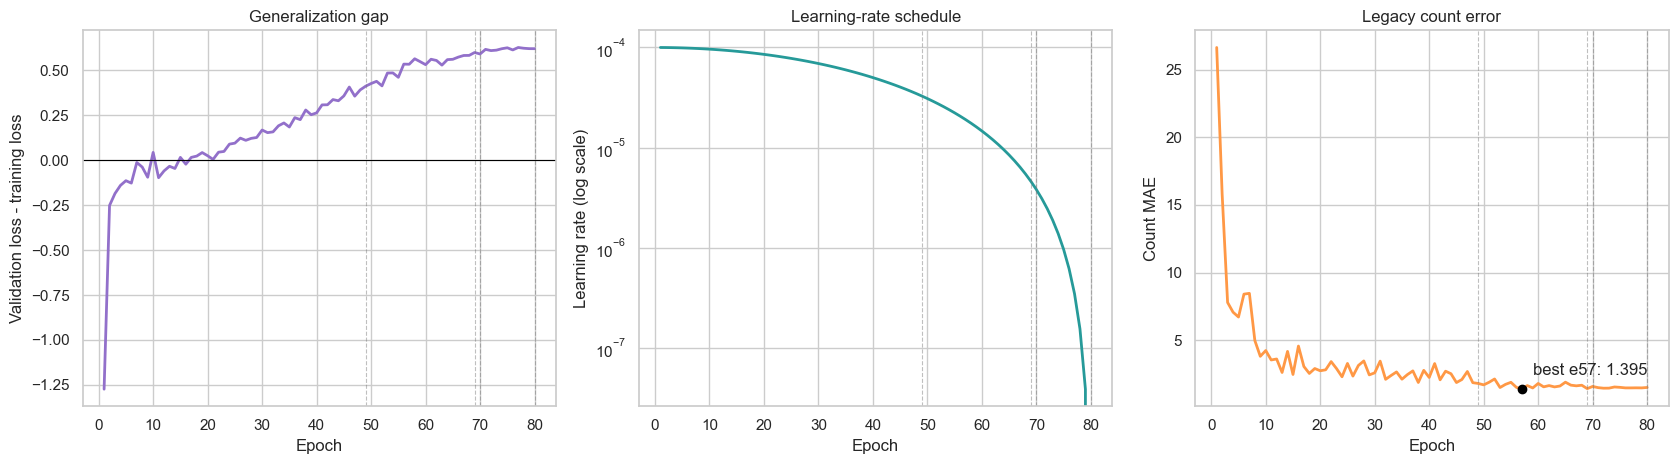

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
gap = train.val_loss - train.train_loss
axes[0].plot(train.epoch, gap, color="#9270CA", lw=2)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(title="Generalization gap", xlabel="Epoch", ylabel="Validation loss - training loss")
axes[1].plot(train.epoch, train.lr, color="#269A99", lw=2)
axes[1].set_yscale("log")
axes[1].set(title="Learning-rate schedule", xlabel="Epoch", ylabel="Learning rate (log scale)")
axes[2].plot(train.epoch, train.count_mae, color="#FF9845", lw=2)
best_count = train.loc[train.count_mae.idxmin()]
axes[2].scatter(best_count.epoch, best_count.count_mae, color="black", zorder=3)
axes[2].annotate(f"best e{int(best_count.epoch)}: {best_count.count_mae:.3f}",
                 (best_count.epoch, best_count.count_mae), xytext=(8, 10), textcoords="offset points")
axes[2].set(title="Legacy count error", xlabel="Epoch", ylabel="Count MAE")
for ax in axes:
    mark_checkpoint_epochs(ax)
finish_figure(fig, "02_gap_lr_count")

## 4. Legacy center metrics across all 80 epochs

These curves use fixed pixel gates and are useful for continuity with training. Cross-source comparisons should favor the normalized `D`-based metrics in the next section because source resolutions differ.

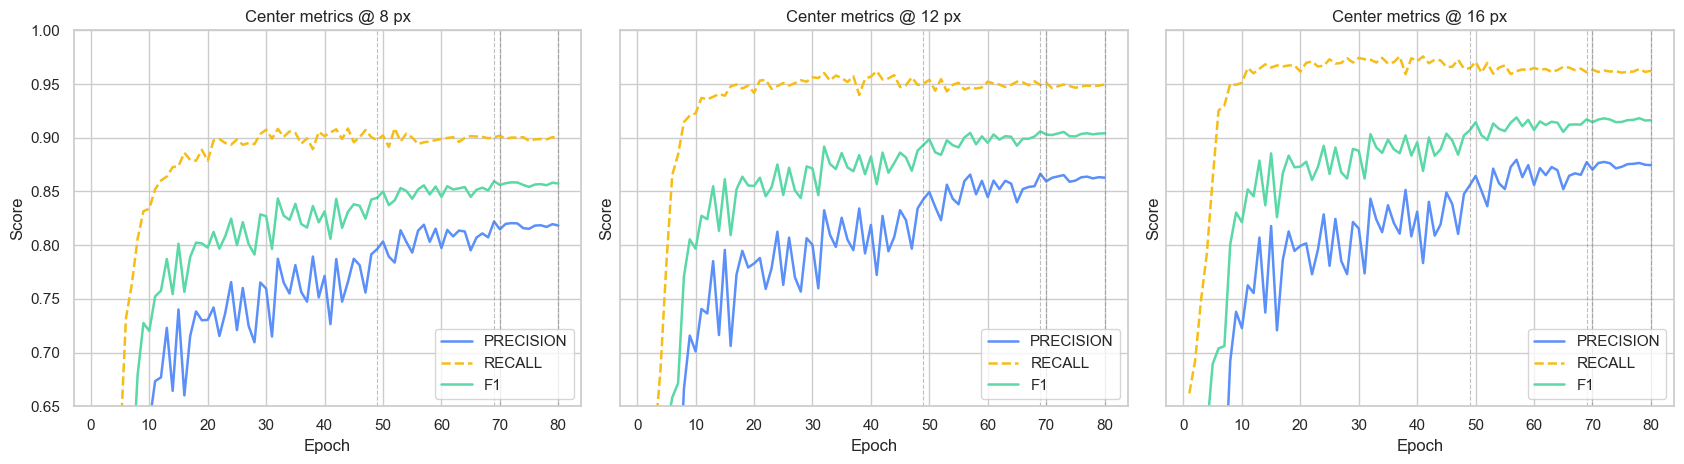

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
metric_styles = {"precision": ("#5B8FF9", "-"), "recall": ("#F6BD16", "--"), "f1": ("#5AD8A6", "-")}
for ax, gate in zip(axes, (8, 12, 16)):
    for metric, (color, style) in metric_styles.items():
        ax.plot(train.epoch, train[f"center_{metric}_{gate}px"], label=metric.upper(), color=color, ls=style, lw=1.8)
    mark_checkpoint_epochs(ax)
    ax.set(title=f"Center metrics @ {gate} px", xlabel="Epoch", ylabel="Score", ylim=(0.65, 1.0))
    ax.legend(loc="lower right")
finish_figure(fig, "03_legacy_center_metrics")

## 5. Detailed normalized validation, epochs 49-80

The plots below track the deployable scorecard. Higher is better for F1, PCK, usable recall, source-macro F1, and worst-source recall. Lower is better for NME, false positives per image, and count MAE.

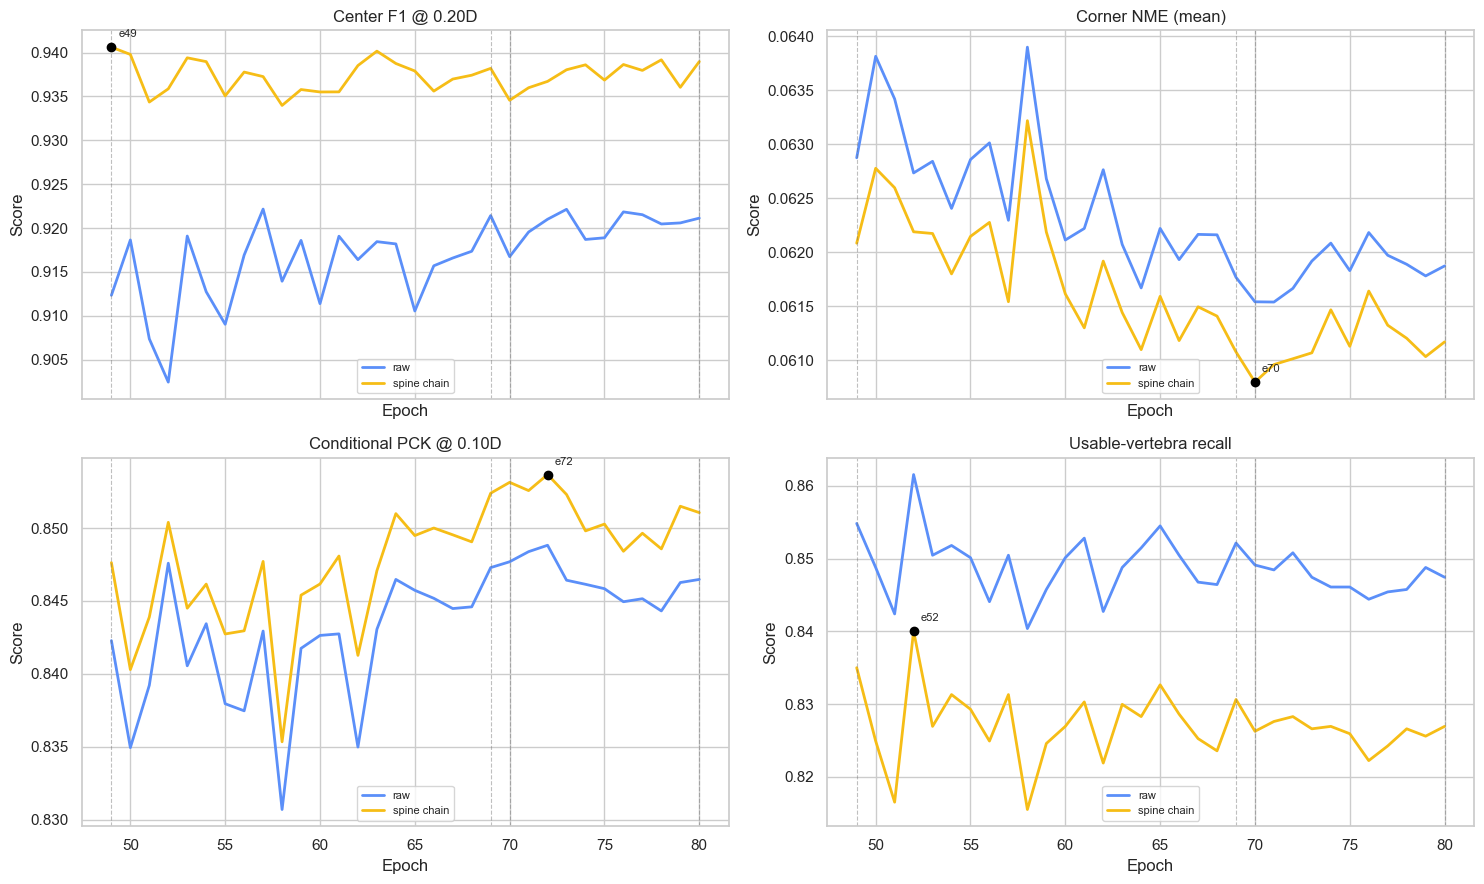

In [7]:
paired_metrics = [
    ("center_f1_0.20d", "Center F1 @ 0.20D", False),
    ("corner_nme_mean", "Corner NME (mean)", True),
    ("pck_0.10", "Conditional PCK @ 0.10D", False),
    ("usable_vertebra_recall", "Usable-vertebra recall", False),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, (suffix, title, lower_is_better) in zip(axes.flat, paired_metrics):
    ax.plot(landmark.epoch, landmark[f"raw_{suffix}"], color=RAW_COLOR, lw=2, label="raw")
    ax.plot(landmark.epoch, landmark[f"spine_chain_{suffix}"], color=CHAIN_COLOR, lw=2, label="spine chain")
    series = landmark[f"spine_chain_{suffix}"]
    best_index = series.idxmin() if lower_is_better else series.idxmax()
    best = landmark.loc[best_index]
    ax.scatter(best.epoch, best[f"spine_chain_{suffix}"], color="black", zorder=4)
    ax.annotate(f"e{int(best.epoch)}", (best.epoch, best[f"spine_chain_{suffix}"]),
                xytext=(5, 7), textcoords="offset points", fontsize=8)
    mark_checkpoint_epochs(ax)
    ax.set(title=title, xlabel="Epoch", ylabel="Score")
    ax.legend(fontsize=8)
finish_figure(fig, "04_normalized_quality_timeline")

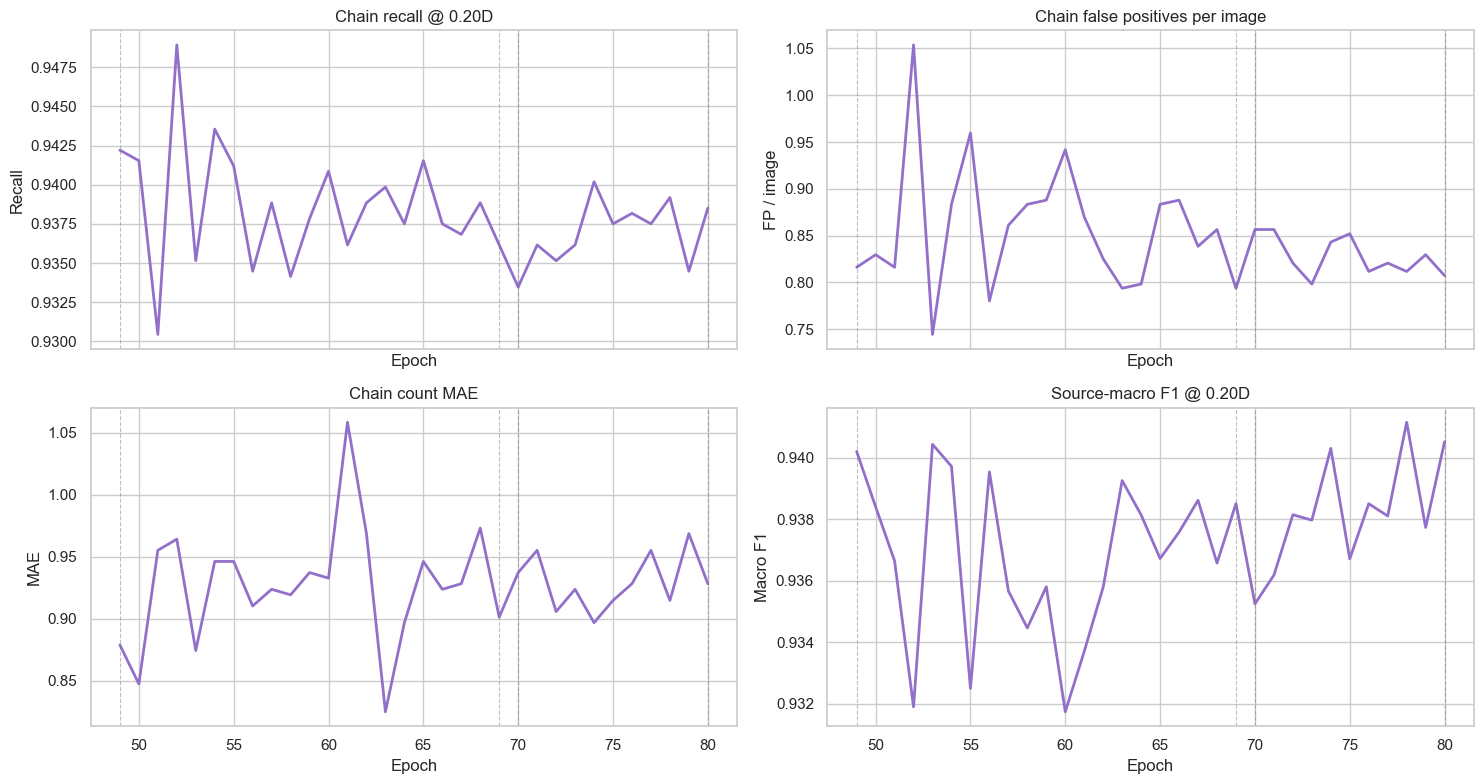

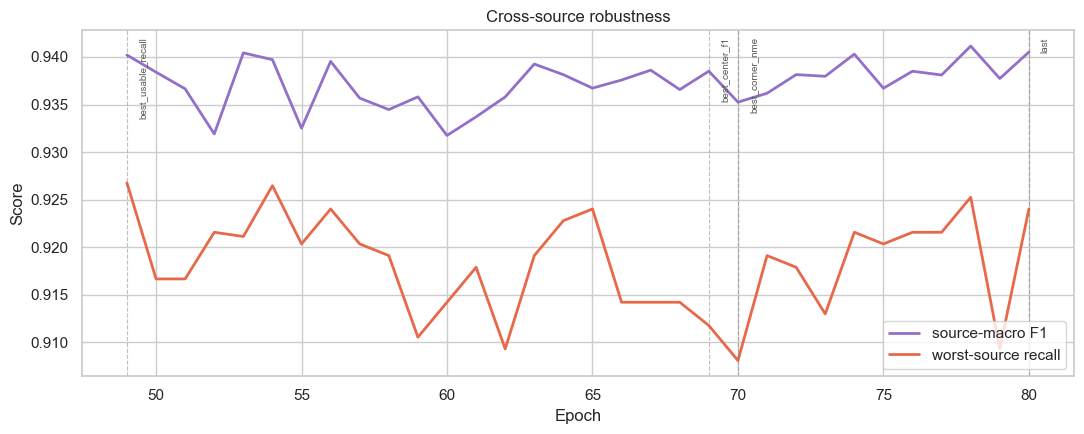

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
operations = [
    ("spine_chain_center_recall_0.20d", "Chain recall @ 0.20D", "Recall"),
    ("spine_chain_false_positives_per_image", "Chain false positives per image", "FP / image"),
    ("spine_chain_count_mae", "Chain count MAE", "MAE"),
    ("spine_chain_source_macro_center_f1_0.20d", "Source-macro F1 @ 0.20D", "Macro F1"),
]
for ax, (column, title, ylabel) in zip(axes.flat, operations):
    ax.plot(landmark.epoch, landmark[column], color="#9270CA", lw=2)
    mark_checkpoint_epochs(ax)
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
finish_figure(fig, "05_chain_operations_and_robustness")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(landmark.epoch, landmark["spine_chain_source_macro_center_f1_0.20d"], label="source-macro F1", color="#9270CA", lw=2)
ax.plot(landmark.epoch, landmark["spine_chain_worst_source_center_recall_0.20d"], label="worst-source recall", color="#E8684A", lw=2)
mark_checkpoint_epochs(ax, labels=True)
ax.set(title="Cross-source robustness", xlabel="Epoch", ylabel="Score")
ax.legend(loc="lower right")
finish_figure(fig, "06_cross_source_robustness")

## 6. Detailed saved-snapshot comparisons

Detailed JSON scorecards are available for epochs 49, 70, and 80. The epoch-69 best-center checkpoint is still shown in the preceding timelines, but it has no matching detailed metrics JSON in this artifact directory.

,snapshot,model,center_precision_0.20d,center_recall_0.20d,center_f1_0.20d,false_positives_per_image,count_mae,corner_nme_mean,pck_0.10,usable_vertebra_recall,cobb_coverage,cobb_mae_deg,cobb_at_5deg,cobb_at_10deg
0,best usable (e49),raw,0.8608,0.9704,0.9123,2.0942,1.8161,0.0629,0.8423,0.8548,1.0000,3.8966,0.7848,0.9462
1,best usable (e49),spine_chain,0.9390,0.9422,0.9406,0.8161,0.8789,0.0621,0.8476,0.8350,1.0000,4.0764,0.7937,0.9372
2,best corner NME (e70),raw,0.8725,0.9657,0.9167,1.8834,1.5964,0.0615,0.8477,0.8491,1.0000,4.0609,0.8027,0.9417
3,best corner NME (e70),spine_chain,0.9357,0.9335,0.9346,0.8565,0.9372,0.0608,0.8531,0.8263,1.0000,3.9010,0.8251,0.9462
4,last (e80),raw,0.8791,0.9674,0.9211,1.7758,1.5202,0.0619,0.8465,0.8474,1.0000,4.0086,0.8072,0.9462
5,last (e80),spine_chain,0.9395,0.9385,0.9390,0.8072,0.9283,0.0612,0.8511,0.8269,1.0000,3.8909,0.8341,0.9462


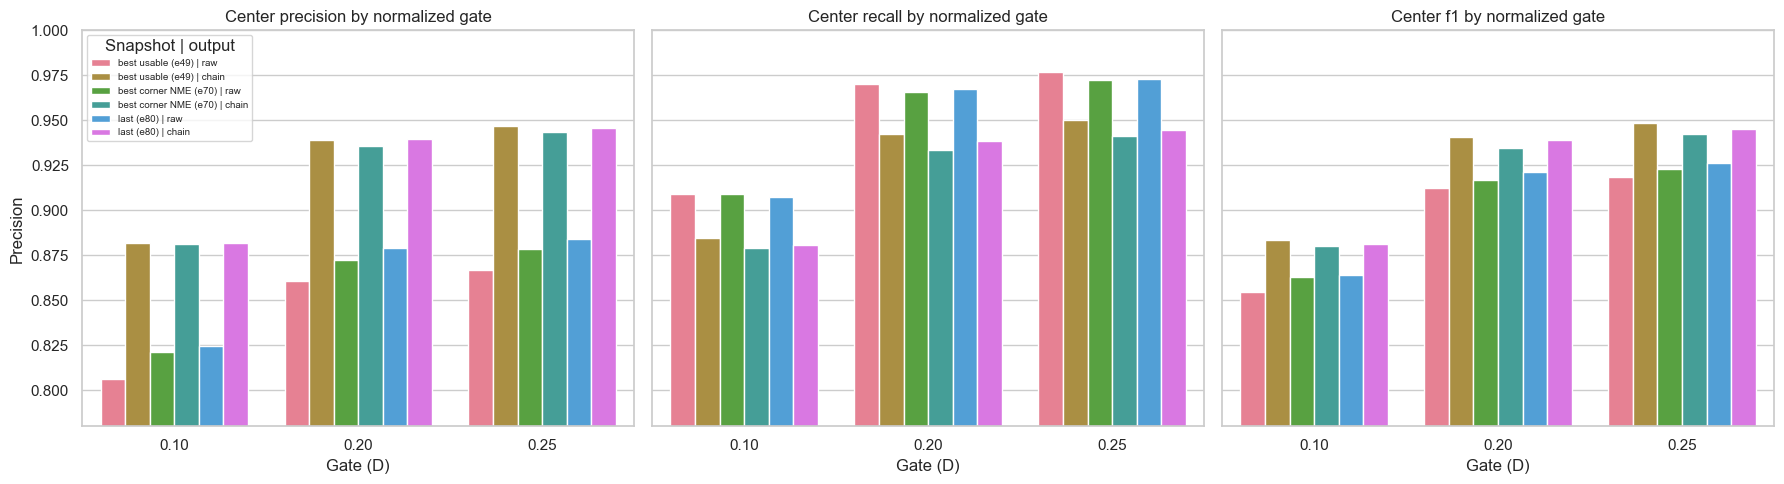

In [9]:
overall_rows = []
for snapshot, payload in metrics_payloads.items():
    for model in ("raw", "spine_chain"):
        row = dict(payload["models"][model]["overall"])
        row.update({"snapshot": snapshot, "epoch": payload["epoch"], "model": model})
        overall_rows.append(row)
overall = pd.DataFrame(overall_rows)

scorecard_columns = [
    "snapshot", "model", "center_precision_0.20d", "center_recall_0.20d", "center_f1_0.20d",
    "false_positives_per_image", "count_mae", "corner_nme_mean", "pck_0.10",
    "usable_vertebra_recall", "cobb_coverage", "cobb_mae_deg", "cobb_at_5deg", "cobb_at_10deg",
]
display(overall[scorecard_columns].style.format({column: "{:.4f}" for column in scorecard_columns[2:]}))

gate_rows = []
for _, row in overall.iterrows():
    for gate in ("0.10", "0.20", "0.25"):
        for metric in ("precision", "recall", "f1"):
            gate_rows.append({
                "snapshot": row.snapshot, "model": row.model, "gate": gate,
                "metric": metric, "value": row[f"center_{metric}_{gate}d"],
            })
gate_metrics = pd.DataFrame(gate_rows)
gate_metrics["series"] = gate_metrics["snapshot"] + " | " + gate_metrics["model"].str.replace("spine_chain", "chain")
series_order = [f"{snapshot} | {model}" for snapshot in metrics_payloads for model in ("raw", "chain")]
series_palette = dict(zip(series_order, sns.color_palette("husl", len(series_order))))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric in zip(axes, ("precision", "recall", "f1")):
    sns.barplot(data=gate_metrics.query("metric == @metric"), x="gate", y="value", hue="series",
                hue_order=series_order, errorbar=None, ax=ax, palette=series_palette)
    ax.set(title=f"Center {metric} by normalized gate", xlabel="Gate (D)", ylabel=metric.title(), ylim=(0.78, 1.0))
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title="Snapshot | output", fontsize=7)
finish_figure(fig, "07_snapshot_center_gates")

The next panel makes post-processing trade-offs explicit. Positive percentage-point changes favor the chain for F1, recall, usable recall, and Cobb-within-5°. Positive FP reduction favors the chain; negative count-MAE change means the chain reduced counting error.

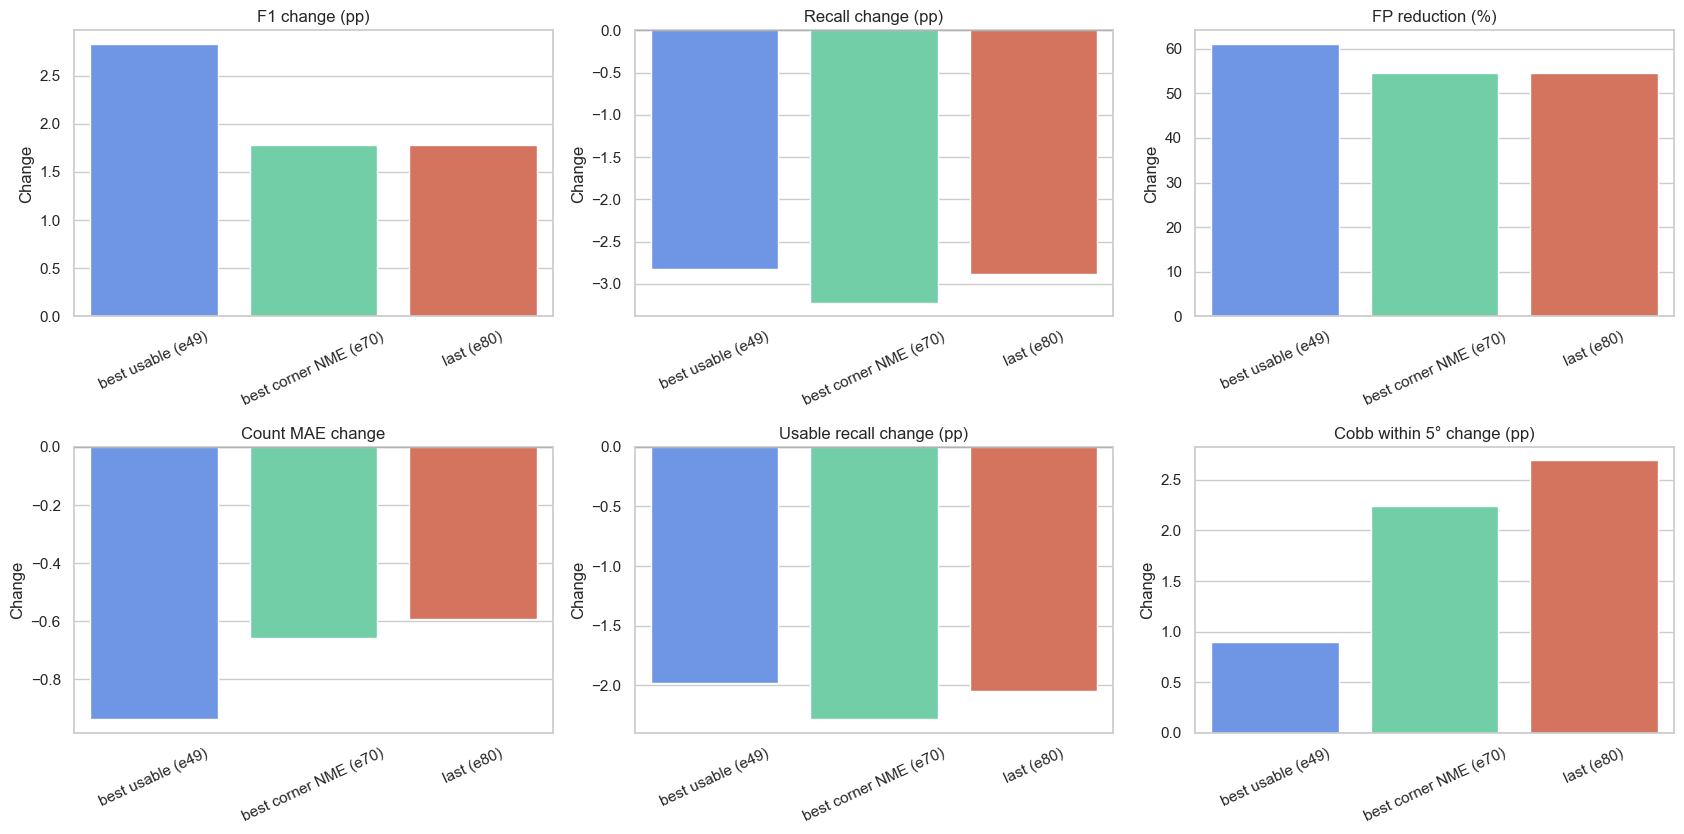

In [10]:
delta_rows = []
for snapshot in metrics_payloads:
    raw = overall.query("snapshot == @snapshot and model == 'raw'").iloc[0]
    chain = overall.query("snapshot == @snapshot and model == 'spine_chain'").iloc[0]
    delta_rows.append({
        "snapshot": snapshot,
        "F1 change (pp)": 100 * (chain["center_f1_0.20d"] - raw["center_f1_0.20d"]),
        "Recall change (pp)": 100 * (chain["center_recall_0.20d"] - raw["center_recall_0.20d"]),
        "FP reduction (%)": 100 * (raw["false_positives_per_image"] - chain["false_positives_per_image"]) / raw["false_positives_per_image"],
        "Count MAE change": chain["count_mae"] - raw["count_mae"],
        "Usable recall change (pp)": 100 * (chain["usable_vertebra_recall"] - raw["usable_vertebra_recall"]),
        "Cobb within 5° change (pp)": 100 * (chain["cobb_at_5deg"] - raw["cobb_at_5deg"]),
    })
deltas = pd.DataFrame(delta_rows)
delta_long = deltas.melt(id_vars="snapshot", var_name="effect", value_name="change")
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
for ax, effect in zip(axes.flat, deltas.columns[1:]):
    subset = delta_long.query("effect == @effect")
    sns.barplot(data=subset, x="snapshot", y="change", hue="snapshot", palette=SNAPSHOT_COLORS,
                legend=False, errorbar=None, ax=ax)
    ax.axhline(0, color="black", lw=0.8)
    ax.set(title=effect, xlabel="", ylabel="Change")
    ax.tick_params(axis="x", rotation=25)
finish_figure(fig, "08_raw_to_chain_effects")

## 7. Source robustness at epoch 80

Per-source panels expose domain imbalance that overall micro metrics can hide. The five sources have different image counts, vertebra sizes, and acquisition characteristics.

,source_dataset,images,gt_vertebrae
0,BUU AP,40,200
1,Lumos AP,16,126
2,MICCAI-2019,48,816
3,Mendeley PA,87,"1,479"
4,NIH ChestX-ray14,32,355


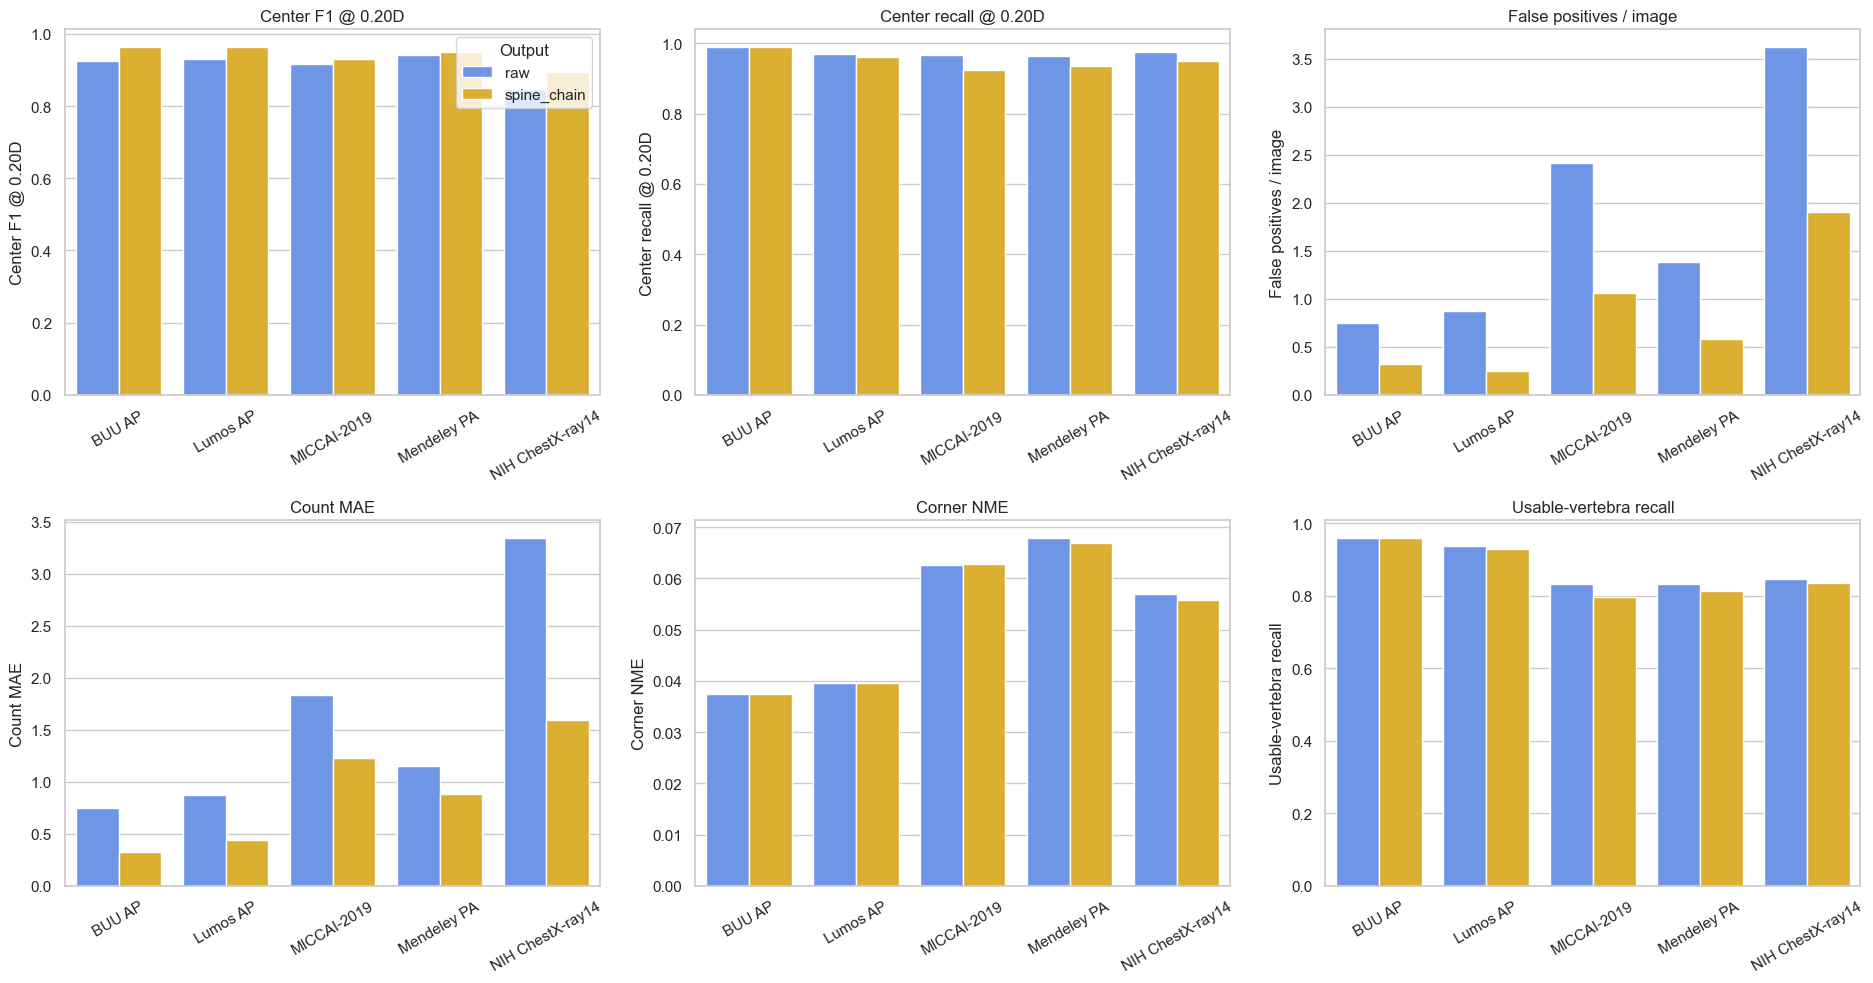

In [11]:
latest_payload = metrics_payloads["last (e80)"]
latest_sources = []
for model in ("raw", "spine_chain"):
    frame = pd.DataFrame(latest_payload["models"][model]["by_source"])
    frame["model"] = model
    latest_sources.append(frame)
latest_sources = pd.concat(latest_sources, ignore_index=True)

source_counts = latest_sources.query("model == 'raw'")[["source_dataset", "images", "gt_vertebrae"]].copy()
display(source_counts.sort_values("source_dataset").style.format({"images": "{:,.0f}", "gt_vertebrae": "{:,.0f}"}))

source_panels = [
    ("center_f1_0.20d", "Center F1 @ 0.20D"),
    ("center_recall_0.20d", "Center recall @ 0.20D"),
    ("false_positives_per_image", "False positives / image"),
    ("count_mae", "Count MAE"),
    ("corner_nme_mean", "Corner NME"),
    ("usable_vertebra_recall", "Usable-vertebra recall"),
]
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (column, title) in zip(axes.flat, source_panels):
    sns.barplot(data=latest_sources, x="source_dataset", y=column, hue="model",
                palette={"raw": RAW_COLOR, "spine_chain": CHAIN_COLOR}, errorbar=None, ax=ax)
    ax.set(title=title, xlabel="", ylabel=title)
    ax.tick_params(axis="x", rotation=30)
    if ax is not axes[0, 0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0, 0].legend(title="Output")
finish_figure(fig, "09_latest_source_robustness")

## 8. Vertebra-scale behavior at epoch 80

Scale bins use vertebral diagonal as a fraction of the image diagonal. This identifies whether small vertebrae drive normalized landmark error or missed usable predictions.

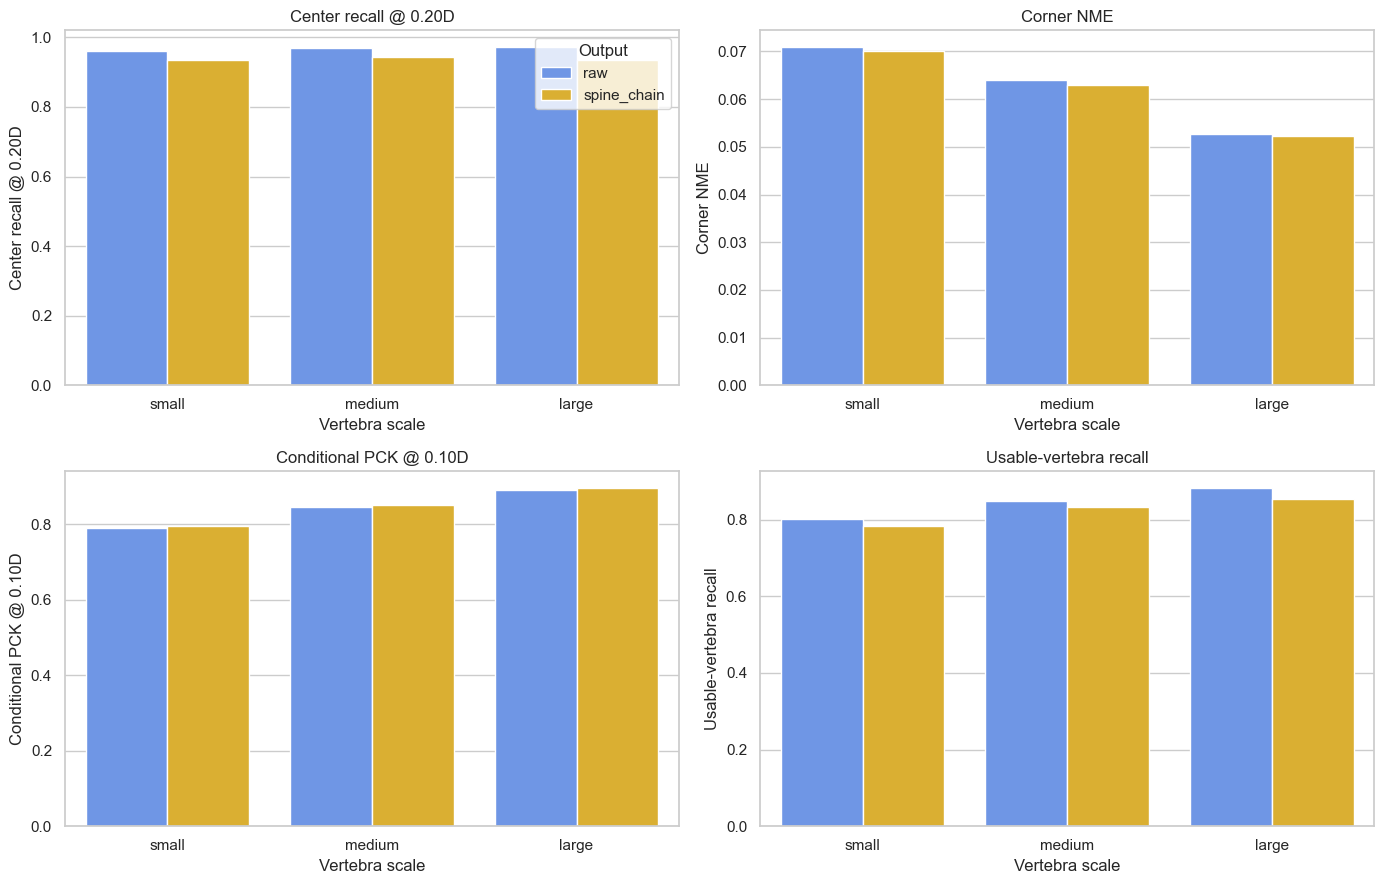

In [12]:
latest_scales = []
for model in ("raw", "spine_chain"):
    frame = pd.DataFrame(latest_payload["models"][model]["by_scale"])
    frame["model"] = model
    latest_scales.append(frame)
latest_scales = pd.concat(latest_scales, ignore_index=True)
scale_order = ["small", "medium", "large"]
scale_panels = [
    ("center_recall_0.20d", "Center recall @ 0.20D"),
    ("corner_nme_mean", "Corner NME"),
    ("pck_0.10", "Conditional PCK @ 0.10D"),
    ("usable_vertebra_recall", "Usable-vertebra recall"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (column, title) in zip(axes.flat, scale_panels):
    sns.barplot(data=latest_scales, x="scale_bin", y=column, order=scale_order, hue="model",
                palette={"raw": RAW_COLOR, "spine_chain": CHAIN_COLOR}, errorbar=None, ax=ax)
    ax.set(title=title, xlabel="Vertebra scale", ylabel=title)
    if ax is not axes[0, 0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0, 0].legend(title="Output")
finish_figure(fig, "10_latest_scale_behavior")

## 9. Cobb geometry agreement

Coverage must be read with error: a low MAE over only a subset of eligible images is not equivalent to low MAE at full coverage. Severity-band rows with zero eligible images are left missing rather than treated as successful zero error.

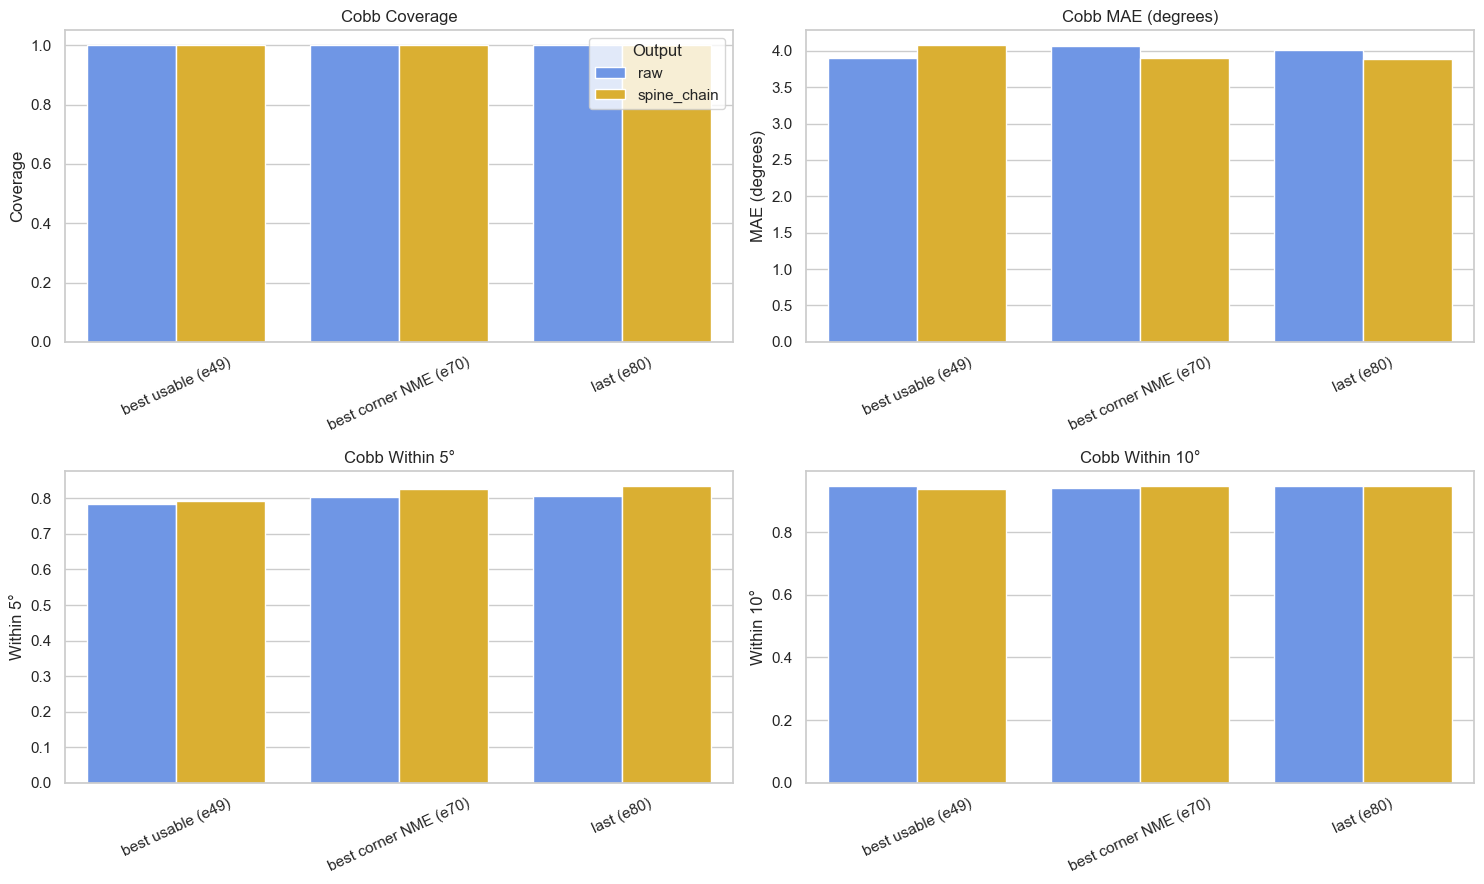

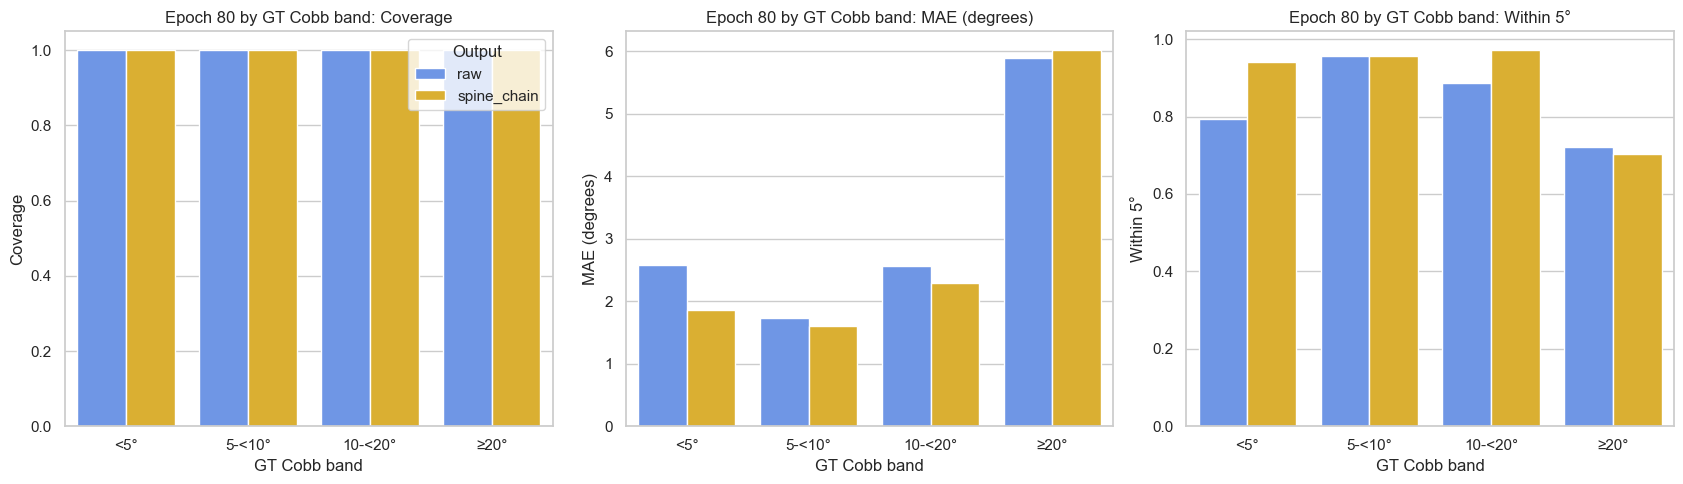

In [13]:
cobb_panels = [
    ("cobb_coverage", "Coverage"),
    ("cobb_mae_deg", "MAE (degrees)"),
    ("cobb_at_5deg", "Within 5°"),
    ("cobb_at_10deg", "Within 10°"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (column, title) in zip(axes.flat, cobb_panels):
    sns.barplot(data=overall, x="snapshot", y=column, hue="model",
                palette={"raw": RAW_COLOR, "spine_chain": CHAIN_COLOR}, errorbar=None, ax=ax)
    ax.set(title=f"Cobb {title}", xlabel="", ylabel=title)
    ax.tick_params(axis="x", rotation=25)
    if ax is not axes[0, 0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0, 0].legend(title="Output")
finish_figure(fig, "11_cobb_snapshot_agreement")

bands = [
    ("lt_5deg", "<5°"),
    ("5_to_lt_10deg", "5-<10°"),
    ("10_to_lt_20deg", "10-<20°"),
    ("ge_20deg", "≥20°"),
]
band_rows = []
for model in ("raw", "spine_chain"):
    row = latest_payload["models"][model]["overall"]
    for prefix, label in bands:
        eligible = row[f"cobb_{prefix}_images"]
        band_rows.append({
            "model": model, "band": label, "eligible_images": eligible,
            "coverage": row[f"cobb_{prefix}_coverage"] if eligible else np.nan,
            "mae_deg": row[f"cobb_{prefix}_mae_deg"] if eligible else np.nan,
            "within_5deg": row[f"cobb_{prefix}_at_5deg"] if eligible else np.nan,
        })
band_metrics = pd.DataFrame(band_rows)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (column, title) in zip(axes, (("coverage", "Coverage"), ("mae_deg", "MAE (degrees)"), ("within_5deg", "Within 5°"))):
    sns.barplot(data=band_metrics, x="band", y=column, hue="model",
                palette={"raw": RAW_COLOR, "spine_chain": CHAIN_COLOR}, errorbar=None, ax=ax)
    ax.set(title=f"Epoch 80 by GT Cobb band: {title}", xlabel="GT Cobb band", ylabel=title)
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title="Output")
finish_figure(fig, "12_cobb_severity_bands")

## 10. Technical guardrails saved with each detailed snapshot

These are the four training-time checkpoint guardrails stored in the JSON artifacts. They are not the larger acceptance suite used by the standalone research evaluator.

,snapshot,check,observed,operator,threshold,passed
0,best usable (e49),source_macro_center_f1_0.20d,0.9402,>=,0.8500,True
1,best usable (e49),worst_source_recall_0.20d,0.9268,>=,0.7500,True
2,best usable (e49),false_positives_per_image,0.8161,<=,1.0000,True
3,best usable (e49),count_mae,0.8789,<=,1.5000,True
4,best corner NME (e70),source_macro_center_f1_0.20d,0.9352,>=,0.8500,True
5,best corner NME (e70),worst_source_recall_0.20d,0.9081,>=,0.7500,True
6,best corner NME (e70),false_positives_per_image,0.8565,<=,1.0000,True
7,best corner NME (e70),count_mae,0.9372,<=,1.5000,True
8,last (e80),source_macro_center_f1_0.20d,0.9405,>=,0.8500,True
9,last (e80),worst_source_recall_0.20d,0.9240,>=,0.7500,True


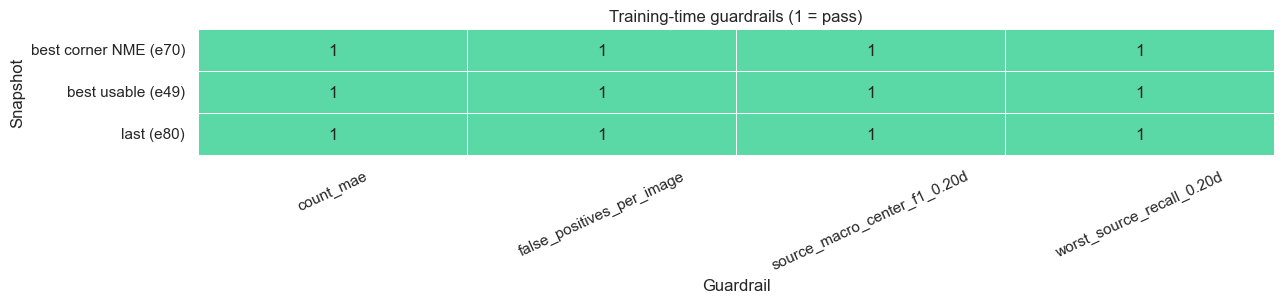

In [14]:
guardrail_rows = []
for snapshot, payload in metrics_payloads.items():
    checks = payload["checkpoint_guardrails"]["checks"]
    for check, detail in checks.items():
        guardrail_rows.append({
            "snapshot": snapshot, "check": check, "observed": detail["observed"],
            "operator": detail["operator"], "threshold": detail["threshold"], "passed": bool(detail["passed"]),
        })
guardrails = pd.DataFrame(guardrail_rows)
display(guardrails.style.format({"observed": "{:.4f}", "threshold": "{:.4f}"}))
matrix = guardrails.pivot(index="snapshot", columns="check", values="passed").astype(int)
fig, ax = plt.subplots(figsize=(13, 3.2))
sns.heatmap(matrix, annot=True, fmt="d", cmap=sns.color_palette(["#E8684A", "#5AD8A6"], as_cmap=True),
            vmin=0, vmax=1, cbar=False, linewidths=0.5, ax=ax)
ax.set(title="Training-time guardrails (1 = pass)", xlabel="Guardrail", ylabel="Snapshot")
ax.tick_params(axis="x", rotation=25)
finish_figure(fig, "13_checkpoint_guardrails")

## 11. Per-instance error distributions

ECDFs retain the full distribution more faithfully than a single mean. Curves further left indicate smaller errors. The x-axis is clipped at the pooled 99th percentile for readability; all rows remain in the summary metrics above.

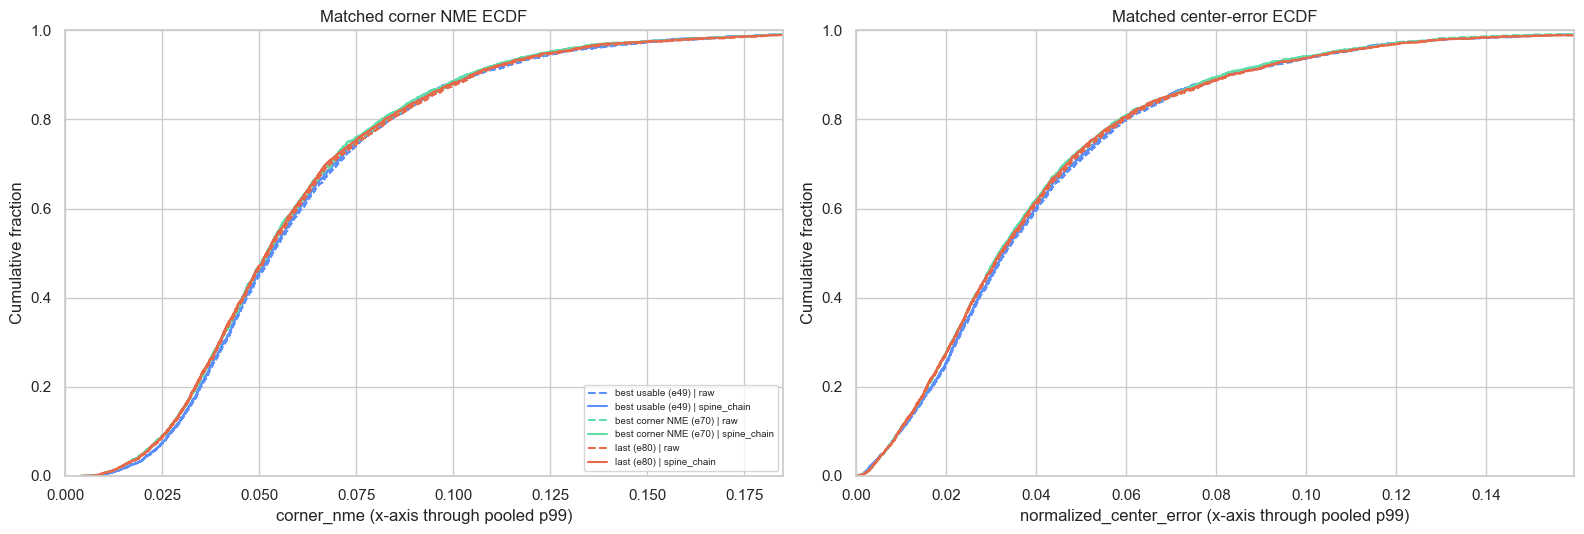

In [15]:
matched = instances.query("status == 'matched'").copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for snapshot, color in SNAPSHOT_COLORS.items():
    for model, linestyle in (("raw", "--"), ("spine_chain", "-")):
        subset = matched.query("snapshot == @snapshot and model == @model")
        sns.ecdfplot(data=subset, x="corner_nme", ax=axes[0], color=color, ls=linestyle,
                     label=f"{snapshot} | {model}")
        sns.ecdfplot(data=subset, x="normalized_center_error", ax=axes[1], color=color, ls=linestyle,
                     label=f"{snapshot} | {model}")
for ax, column, title in ((axes[0], "corner_nme", "Matched corner NME ECDF"),
                          (axes[1], "normalized_center_error", "Matched center-error ECDF")):
    limit = matched[column].quantile(0.99)
    ax.set_xlim(0, limit)
    ax.set(title=title, xlabel=f"{column} (x-axis through pooled p99)", ylabel="Cumulative fraction")
axes[0].legend(fontsize=7, loc="lower right")
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
finish_figure(fig, "14_instance_error_ecdfs")

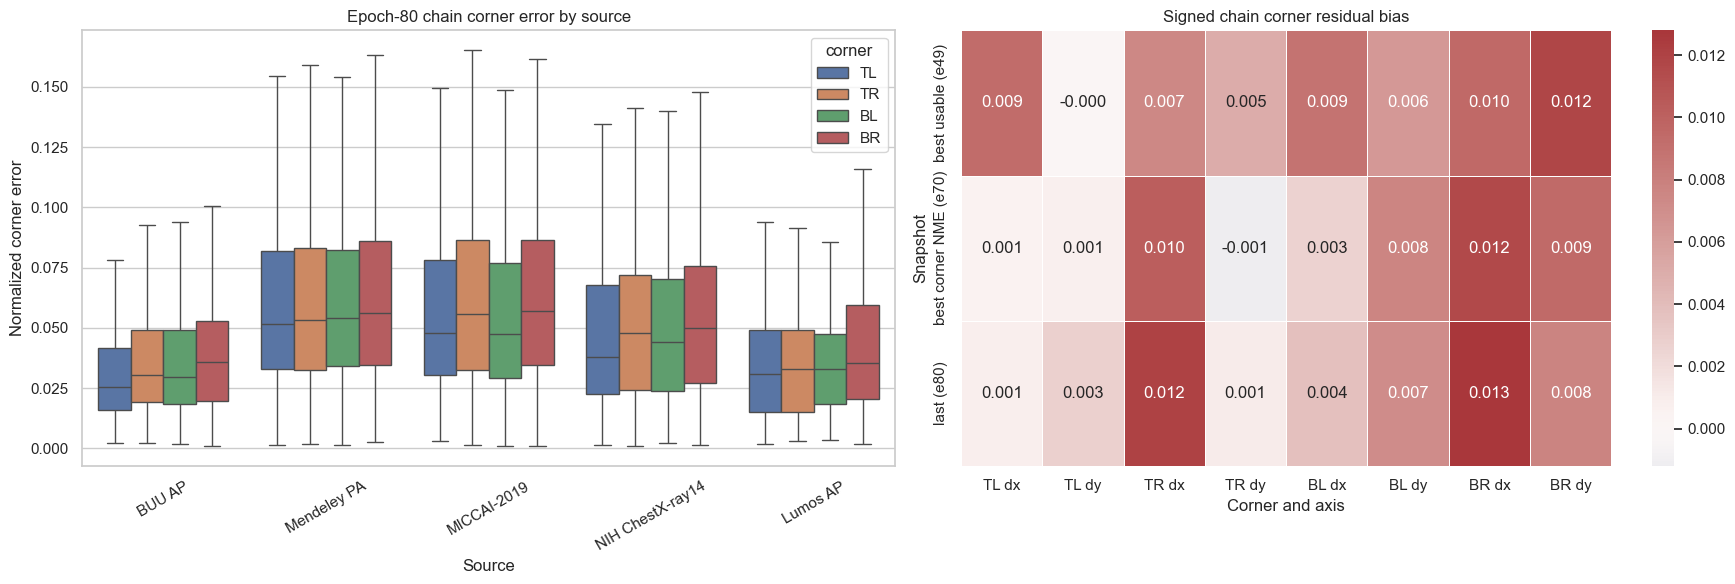

In [16]:
latest_chain_matched = matched.query("snapshot == 'last (e80)' and model == 'spine_chain'").copy()
corner_error_columns = {
    "tl_normalized_error": "TL", "tr_normalized_error": "TR",
    "bl_normalized_error": "BL", "br_normalized_error": "BR",
}
corner_errors = latest_chain_matched[["source_dataset", *corner_error_columns]].melt(
    id_vars="source_dataset", var_name="corner_field", value_name="normalized_error")
corner_errors["corner"] = corner_errors["corner_field"].map(corner_error_columns)

bias_rows = []
for snapshot in SNAPSHOT_COLORS:
    subset = matched.query("snapshot == @snapshot and model == 'spine_chain'")
    row = {"snapshot": snapshot}
    for corner in ("tl", "tr", "bl", "br"):
        row[f"{corner.upper()} dx"] = subset[f"{corner}_dx_normalized"].mean()
        row[f"{corner.upper()} dy"] = subset[f"{corner}_dy_normalized"].mean()
    bias_rows.append(row)
bias = pd.DataFrame(bias_rows).set_index("snapshot")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=corner_errors, x="source_dataset", y="normalized_error", hue="corner",
            hue_order=["TL", "TR", "BL", "BR"], showfliers=False, ax=axes[0])
axes[0].set(title="Epoch-80 chain corner error by source", xlabel="Source", ylabel="Normalized corner error")
axes[0].tick_params(axis="x", rotation=30)
sns.heatmap(bias, annot=True, fmt=".3f", cmap="vlag", center=0, linewidths=0.5, ax=axes[1])
axes[1].set(title="Signed chain corner residual bias", xlabel="Corner and axis", ylabel="Snapshot")
finish_figure(fig, "15_corner_error_and_bias")

## 12. Automatically generated run takeaways

This final cell reports observed facts and simple comparisons. A rising validation gap is a model-selection signal, not proof of clinical overfitting. Confirm checkpoint choice on the held-out test set with the standalone evaluator.

In [17]:
val_best = train.loc[train.val_loss.idxmin()]
legacy_best = train.loc[train.center_f1_12px.idxmax()]
chain_f1_best = landmark.loc[landmark["spine_chain_center_f1_0.20d"].idxmax()]
nme_best = landmark.loc[landmark["spine_chain_corner_nme_mean"].idxmin()]
macro_best = landmark.loc[landmark["spine_chain_source_macro_center_f1_0.20d"].idxmax()]
final_lm = landmark.iloc[-1]
raw_final = overall.query("snapshot == 'last (e80)' and model == 'raw'").iloc[0]
chain_final = overall.query("snapshot == 'last (e80)' and model == 'spine_chain'").iloc[0]
worst_source = latest_sources.query("model == 'spine_chain'").sort_values("center_f1_0.20d").iloc[0]
guardrail_rate = landmark["guardrails_passed"].astype(bool).mean()

takeaways = f"""
- **Optimization:** validation loss reached its minimum at epoch **{int(val_best.epoch)}** ({val_best.val_loss:.4f}); the final validation loss was {train.iloc[-1].val_loss:.4f}, while training loss continued to {train.iloc[-1].train_loss:.4f}.
- **Legacy center selection:** 12-pixel center F1 peaked at epoch **{int(legacy_best.epoch)}** ({legacy_best.center_f1_12px:.4f}), matching `best_center_f1.pt`.
- **Normalized detection:** chain F1@0.20D peaked at epoch **{int(chain_f1_best.epoch)}** ({chain_f1_best['spine_chain_center_f1_0.20d']:.4f}); epoch 80 ended at {final_lm['spine_chain_center_f1_0.20d']:.4f}.
- **Landmarks:** the lowest chain mean NME occurred at epoch **{int(nme_best.epoch)}** ({nme_best['spine_chain_corner_nme_mean']:.4f}); epoch 80 ended at {final_lm['spine_chain_corner_nme_mean']:.4f}.
- **Source robustness:** source-macro chain F1@0.20D peaked at epoch **{int(macro_best.epoch)}** ({macro_best['spine_chain_source_macro_center_f1_0.20d']:.4f}). At epoch 80, the lowest per-source chain F1 was **{worst_source.source_dataset}** ({worst_source['center_f1_0.20d']:.4f}).
- **Post-processing at epoch 80:** the chain changed F1@0.20D from {raw_final['center_f1_0.20d']:.4f} to {chain_final['center_f1_0.20d']:.4f}, FP/image from {raw_final['false_positives_per_image']:.3f} to {chain_final['false_positives_per_image']:.3f}, and count MAE from {raw_final['count_mae']:.3f} to {chain_final['count_mae']:.3f}.
- **Cobb geometry at epoch 80:** chain coverage was {chain_final['cobb_coverage']:.1%}, MAE was {chain_final['cobb_mae_deg']:.2f}°, and within-5° agreement was {chain_final['cobb_at_5deg']:.1%}.
- **Training guardrails:** {guardrail_rate:.1%} of detailed-validation epochs passed the recorded four-check training guardrail set.
- **Next decision:** compare the retained checkpoints on the unchanged held-out test set. Do not choose `last.pt` solely because it is the latest epoch.
"""
display(Markdown(takeaways))


- **Optimization:** validation loss reached its minimum at epoch **35** (1.0527); the final validation loss was 1.2246, while training loss continued to 0.6033.
- **Legacy center selection:** 12-pixel center F1 peaked at epoch **69** (0.9060), matching `best_center_f1.pt`.
- **Normalized detection:** chain F1@0.20D peaked at epoch **49** (0.9406); epoch 80 ended at 0.9390.
- **Landmarks:** the lowest chain mean NME occurred at epoch **70** (0.0608); epoch 80 ended at 0.0612.
- **Source robustness:** source-macro chain F1@0.20D peaked at epoch **78** (0.9411). At epoch 80, the lowest per-source chain F1 was **NIH ChestX-ray14** (0.8951).
- **Post-processing at epoch 80:** the chain changed F1@0.20D from 0.9211 to 0.9390, FP/image from 1.776 to 0.807, and count MAE from 1.520 to 0.928.
- **Cobb geometry at epoch 80:** chain coverage was 100.0%, MAE was 3.89°, and within-5° agreement was 83.4%.
- **Training guardrails:** 96.9% of detailed-validation epochs passed the recorded four-check training guardrail set.
- **Next decision:** compare the retained checkpoints on the unchanged held-out test set. Do not choose `last.pt` solely because it is the latest epoch.


## Metric glossary

- **Center precision / recall / F1:** one-to-one center matching at the stated gate. `0.20D` means a prediction is eligible when its center is within 20% of the matched GT vertebra diagonal.
- **FP/image:** unmatched predicted centers divided by images.
- **Count MAE:** mean absolute difference between predicted and ground-truth vertebra counts per image.
- **Corner NME:** mean TL/TR/BL/BR Euclidean error normalized by GT vertebra diagonal.
- **Conditional PCK@0.10:** fraction of corners within 0.10D among matched detections.
- **Usable-vertebra recall:** fraction of all GT vertebrae with a matched prediction satisfying the evaluator's landmark-geometry usability rules.
- **Source macro / worst source:** equal-weight average across sources / lowest source-level result, reducing domination by larger sources.
- **Cobb coverage:** fraction of eligible images with a valid geometric prediction; error statistics are conditional on valid predictions.
- **Signed residual bias:** prediction minus GT. Positive `dx` is rightward and positive `dy` is downward in image coordinates.